Decision Tree Classifier

Decision Tree Model
-------------------
Median Salary: 29.73
Accuracy: 0.93
Accuracy Percentage: 93.0 %

Actual vs Predicted Salary Class
   Experience_Years  Actual Salary Class  Predicted Salary Class
0                 3                    0                       0
1                 7                    1                       0
2                16                    1                       1
3                 1                    0                       0
4                 4                    0                       0
5                 0                    0                       0
6                12                    1                       1
7                20                    1                       1
8                17                    1                       1
9                 3                    0                       0


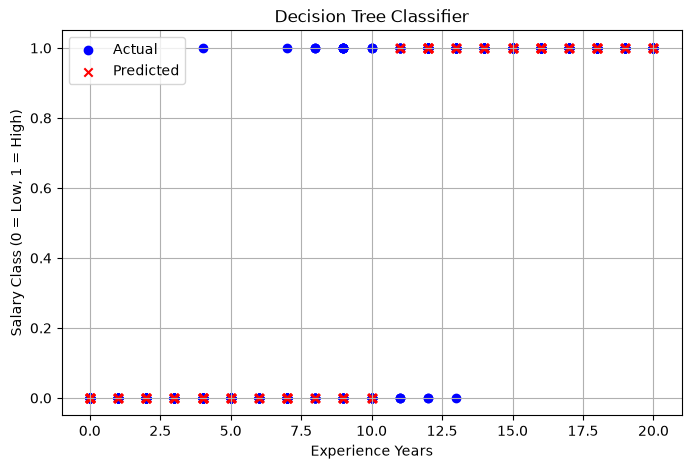

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv("preprocessed_data.csv")
median_salary = df["Salary_LPA"].median()
df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)
X = df[["Experience_Years"]]
y = df["Salary_Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Model")
print("-------------------")
print("Median Salary:", median_salary)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")
result = pd.DataFrame({
    "Experience_Years": X_test["Experience_Years"].values,
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})
print("\nActual vs Predicted Salary Class")
print(result.head(10))
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test["Experience_Years"],
    y_test,
    color="blue",
    label="Actual"
)
plt.scatter(
    X_test["Experience_Years"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted"
)
plt.title("Decision Tree Classifier")
plt.xlabel("Experience Years")
plt.ylabel("Salary Class (0 = Low, 1 = High)")
plt.legend()
plt.grid(True)
plt.show()

Decision Tree 

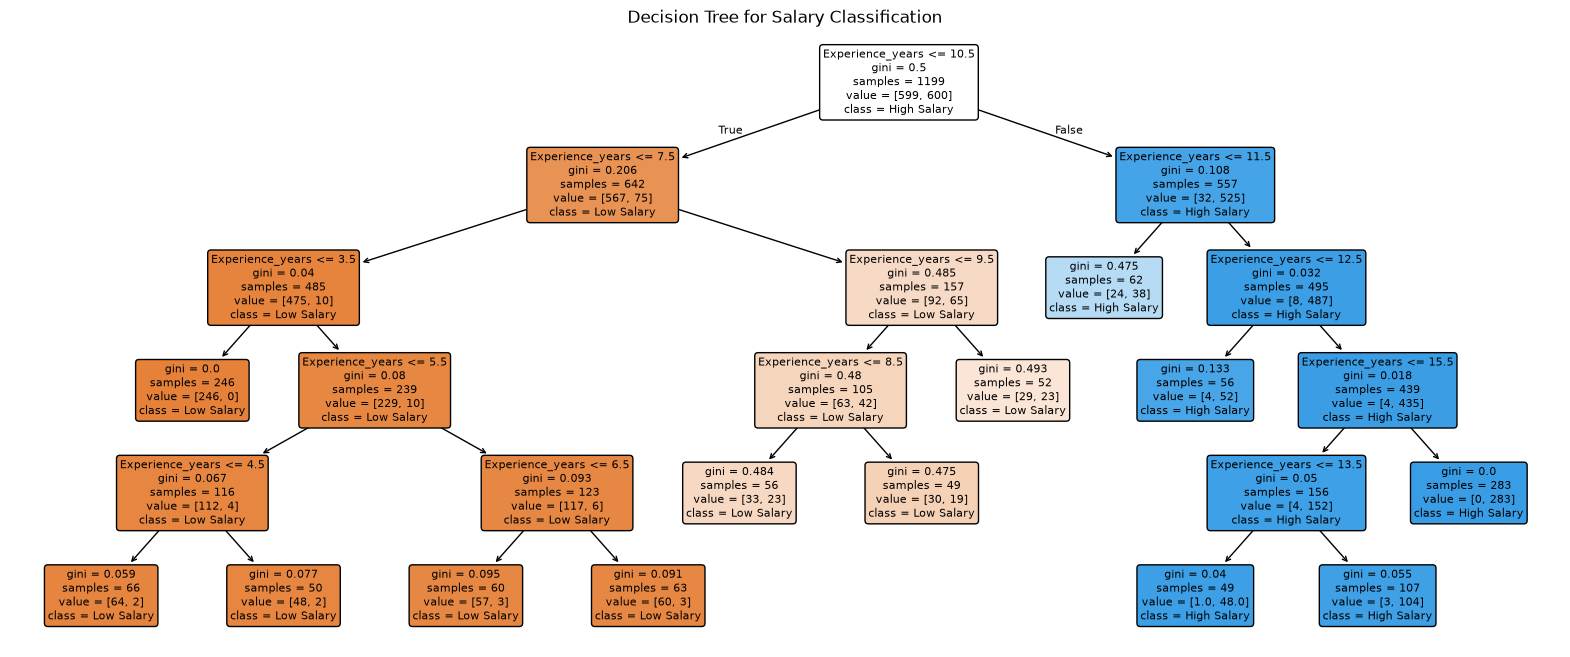

In [5]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,8))
plot_tree(
    model,
    feature_names=["Experience_years"],
    class_names=["Low Salary","High Salary"],
    rounded=True,
    filled=True,
    fontsize=8
)
plt.title("Decision Tree for Salary Classification")
plt.show()

Evaluation Matrices

Decision Tree Model
-------------------
Median Salary: 29.73
Accuracy: 0.93
Confusion matrix:  [[144   6]
 [ 15 135]]
Classification_report:                precision    recall  f1-score   support

           0       0.91      0.96      0.93       150
           1       0.96      0.90      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

f1_score:  0.9278350515463918
recall_score: 0.9
precision_score:  0.9574468085106383

Actual vs Predicted Salary Class
   Experience_Years  Actual Salary Class  Predicted Salary Class
0                 3                    0                       0
1                 7                    1                       0
2                16                    1                       1
3                 1                    0                       0
4                 4                    0                       0
5                 0   

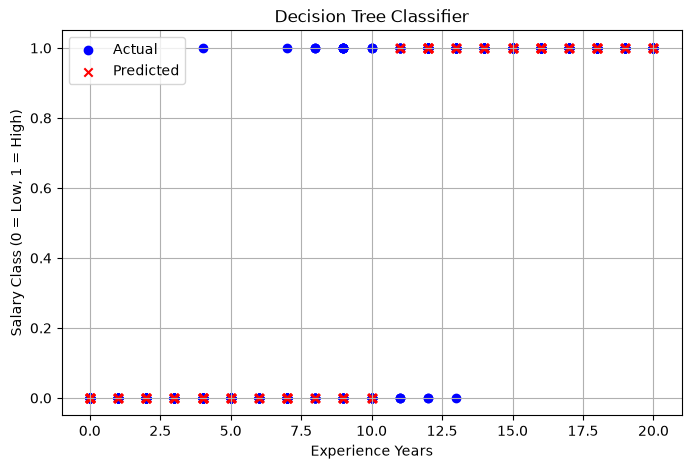

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score , recall_score , precision_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv("preprocessed_data.csv")
median_salary = df["Salary_LPA"].median()

df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)
X = df[["Experience_Years"]]
y = df["Salary_Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("Decision Tree Model")
print("-------------------")
print("Median Salary:", median_salary)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",confusion_matrix)

classification_report = classification_report(y_test,y_pred)
print("Classification_report: ",classification_report)

f1_score = f1_score(y_test,y_pred)
print("f1_score: ",f1_score)

recall_score = recall_score(y_test,y_pred)
print("recall_score:",recall_score)

precision_score = precision_score(y_test,y_pred)
print("precision_score: ",precision_score)


result = pd.DataFrame({
    "Experience_Years": X_test["Experience_Years"].values,
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary Class")
print(result.head(10))


plt.figure(figsize=(8, 5))
plt.scatter(
    X_test["Experience_Years"],
    y_test,
    color="blue",
    label="Actual"
)
plt.scatter(
    X_test["Experience_Years"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted"
)
plt.title("Decision Tree Classifier")
plt.xlabel("Experience Years")
plt.ylabel("Salary Class (0 = Low, 1 = High)")
plt.legend()
plt.grid(True)
plt.show()

Mae and R2

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mean_absolute_error = mean_absolute_error(y_test, y_pred)
mean_squared_error = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error ** 0.5
r2 = r2_score(y_test, y_pred)
print("MAE :", mean_absolute_error)
print("MSE :", mean_squared_error)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.07
MSE : 0.07
RMSE: 0.2645751311064591
R2 Score: 0.72


Heat map and correlation matrix

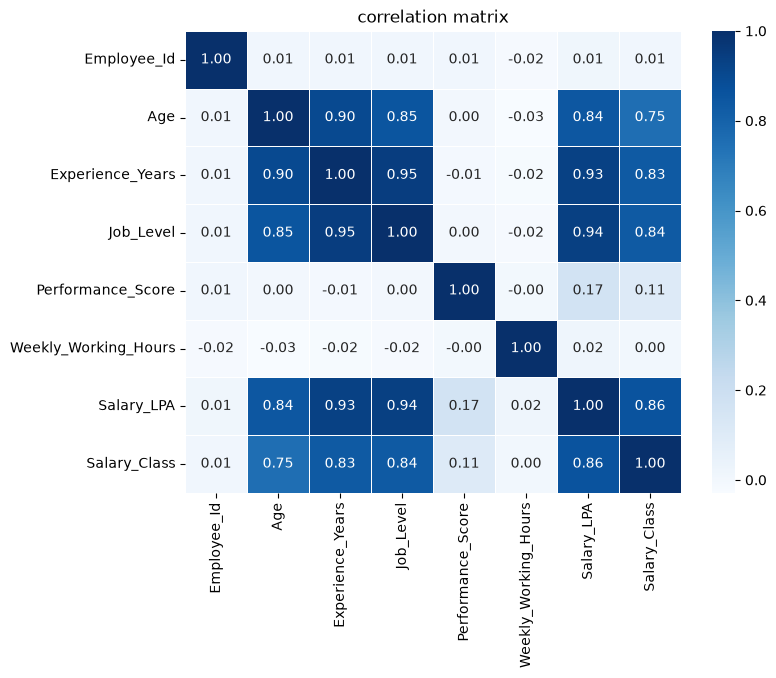

In [9]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix")
plt.show()